In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "henokyoseph",\n  "key": "KGAT_e6c39786f5cb6bcf186c90b6d231eb15"\n}'}

## Data Collection

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d itamargr/dfdc-faces-of-the-train-sample

Dataset URL: https://www.kaggle.com/datasets/itamargr/dfdc-faces-of-the-train-sample
License(s): ODbL-1.0
100% 3.64G/3.64G [03:37<00:00, 18.0MB/s]



## Data Extraction

In [4]:
import zipfile

with zipfile.ZipFile("dfdc-faces-of-the-train-sample.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [5]:
!find data/train -type f | wc -l
!find data/validation -type f | wc -l

93853
30794


## Install & Import Libraries

In [6]:
!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.layers import (TimeDistributed, Conv2D, MaxPooling2D,
                                     Flatten, Dense, Dropout, LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [7]:
import tensorflow as tf
print(tf.version.VERSION)

2.19.0


In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Parameters

In [8]:
IMG_SIZE = 96
SEQUENCE_LENGTH = 4
BATCH_SIZE = 8

## Data Loader (Sequence Generator)

In [9]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_dir, batch_size, seq_len, img_size):
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.img_size = img_size

        self.samples = []
        self.labels = []

        classes = ['real', 'fake']

        for label, cls in enumerate(classes):
            class_path = os.path.join(data_dir, cls)
            images = os.listdir(class_path)

            # group into sequences
            for i in range(0, len(images) - seq_len, seq_len):
                seq_paths = [os.path.join(class_path, images[i+j]) for j in range(seq_len)]
                self.samples.append(seq_paths)
                self.labels.append(label)

    def __len__(self):
        return len(self.samples) // self.batch_size

    def __getitem__(self, idx):
        batch_x = []
        batch_y = []

        batch_samples = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]

        for i, seq_paths in enumerate(batch_samples):
            seq = []

            for img_path in seq_paths:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.resize(img, (self.img_size, self.img_size))
                img = img / 255.0
                seq.append(img)

            if len(seq) == self.seq_len:
                batch_x.append(seq)
                batch_y.append(self.labels[idx*self.batch_size + i])

        return np.array(batch_x), np.array(batch_y)

## Load Dataset and Create Generators

In [10]:
train_path = '/content/data/train'
val_path = '/content/data/validation'

train_gen = DataGenerator(train_path, BATCH_SIZE, SEQUENCE_LENGTH, IMG_SIZE)
val_gen = DataGenerator(val_path, BATCH_SIZE, SEQUENCE_LENGTH, IMG_SIZE)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))

Train batches: 2932
Validation batches: 962


## Build CNN + LSTM Model

In [24]:
model = Sequential()

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                          input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Conv2D(128, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Flatten()))

model.add(LSTM(64, dropout=0.4, recurrent_dropout=0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 3e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_7              │ (None, 4, 94, 94, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 4, 47, 47, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 4, 45, 45, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 4, 22, 22, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 4, 20, 20, 128) │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 4, 10, 10, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 4, 12800)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │     3,293,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,390,913 (12.94 MB)

 Trainable params: 3,390,913 (12.94 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
class_weights = {0: 1.5, 1: 1.0}

print(class_weights)

{0: 1.5, 1: 1.0}


## Callbacks

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                # longer patience
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,                # reduce LR earlier
    min_lr=1e-6,
    verbose=1
)

## Train Model

In [27]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights
)

Epoch 1/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 208s 69ms/step - accuracy: 0.8109 - loss: 0.5704 - val_accuracy: 0.7705 - val_loss: 0.5345 - learning_rate: 3.0000e-05
Epoch 2/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 193s 66ms/step - accuracy: 0.8898 - loss: 0.3393 - val_accuracy: 0.8112 - val_loss: 0.6104 - learning_rate: 3.0000e-05
Epoch 3/15
2931/2932 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9260 - loss: 0.2476
Epoch 3: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 193s 66ms/step - accuracy: 0.9328 - loss: 0.2239 - val_accuracy: 0.8151 - val_loss: 0.6286 - learning_rate: 3.0000e-05
Epoch 4/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 192s 66ms/step - accuracy: 0.9537 - loss: 0.1613 - val_accuracy: 0.8241 - val_loss: 0.5943 - learning_rate: 9.0000e-06
Epoch 5/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9560 - loss: 0.1503
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 193s 

## Plot Training

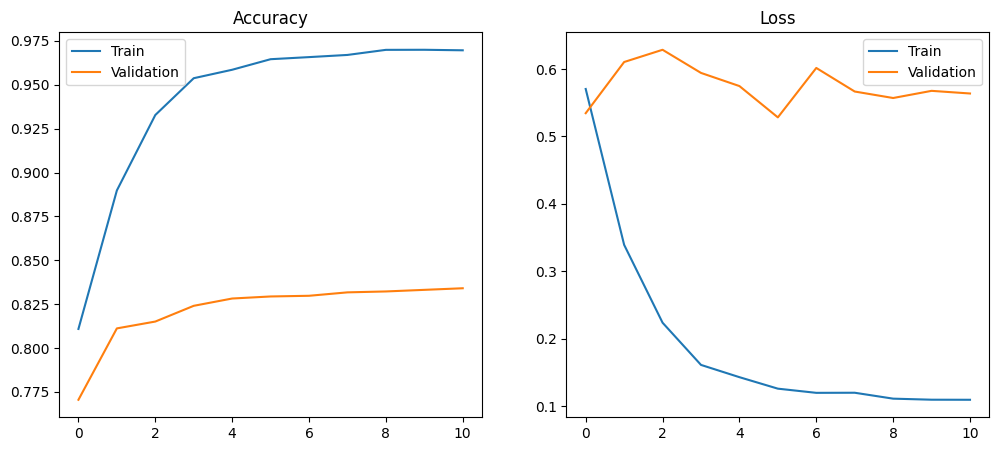

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.show()

## Predictions

In [29]:
y_true = []
y_pred_probs = []

for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]
    preds = model.predict(X_batch)

    y_true.extend(y_batch)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━

## Confusion Matrix

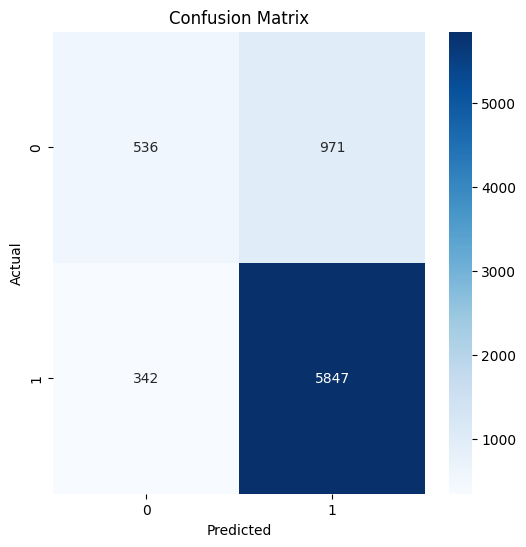

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##  Evaluation Metrics

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8293918918918919
Precision: 0.8091958502935768
Recall   : 0.8293918918918919
F1 Score : 0.8110196950309531


## ROC Curve

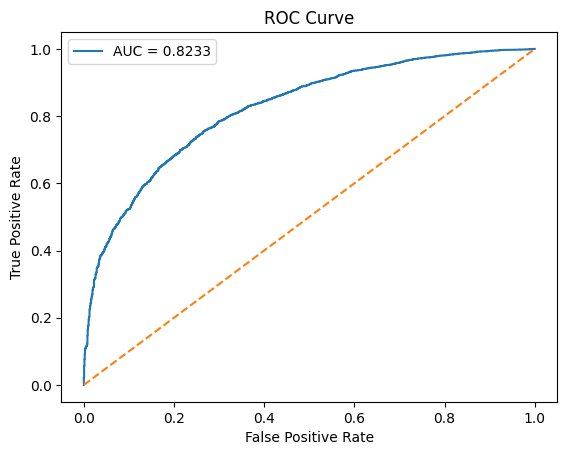

In [38]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
model.save('/content/Deepfake_CNN_LSTM.h5')